<a href="https://colab.research.google.com/github/Yashlad041/Edunet-Intership-tasks-/blob/main/Day-7_13-07-2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

Task 2: Load Dataset

In [17]:
df = pd.read_csv("/content/climate_change_indicators-selected-columns.csv")

df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator..."
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator..."
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator..."
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator..."
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator..."


Task 3: Dataset Information

In [3]:
print("Shape :", df.shape)

df.info()

df.describe(include="all")

Shape : (225, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ObjectId             225 non-null    int64 
 1   Country              225 non-null    object
 2   ISO2                 223 non-null    object
 3   ISO3                 225 non-null    object
 4   Indicator            225 non-null    object
 5   Unit                 225 non-null    object
 6   Source               225 non-null    object
 7   CTS_Code             225 non-null    object
 8   CTS_Name             225 non-null    object
 9   CTS_Full_Descriptor  225 non-null    object
dtypes: int64(1), object(9)
memory usage: 17.7+ KB


,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor
count,225.000000,225,223,225,225,225,225,225,225,225
unique,NaN,225,223,225,1,1,1,1,1,1
top,NaN,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator..."
freq,NaN,1,1,1,225,225,225,225,225,225
mean,113.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,65.096083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,113.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,169.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Task 4: Check Missing Values

In [4]:
df.isnull().sum()

,0
ObjectId,0
Country,0
ISO2,2
ISO3,0
Indicator,0
Unit,0
Source,0
CTS_Code,0
CTS_Name,0
CTS_Full_Descriptor,0


Task 5: Remove Missing Values

In [5]:
df.dropna(inplace=True)

print(df.shape)

(223, 10)


Task 6: Remove Duplicate Records

In [6]:
df.drop_duplicates(inplace=True)

print(df.shape)

(223, 10)


Task 7: Encode Categorical Columns

In [7]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor
0,1,0,2,1,0,0,0,0,0,0
1,2,1,5,4,0,0,0,0,0,0
2,3,2,51,53,0,0,0,0,0,0
3,4,3,9,9,0,0,0,0,0,0
4,5,4,0,5,0,0,0,0,0,0


Task 8: Correlation Heatmap

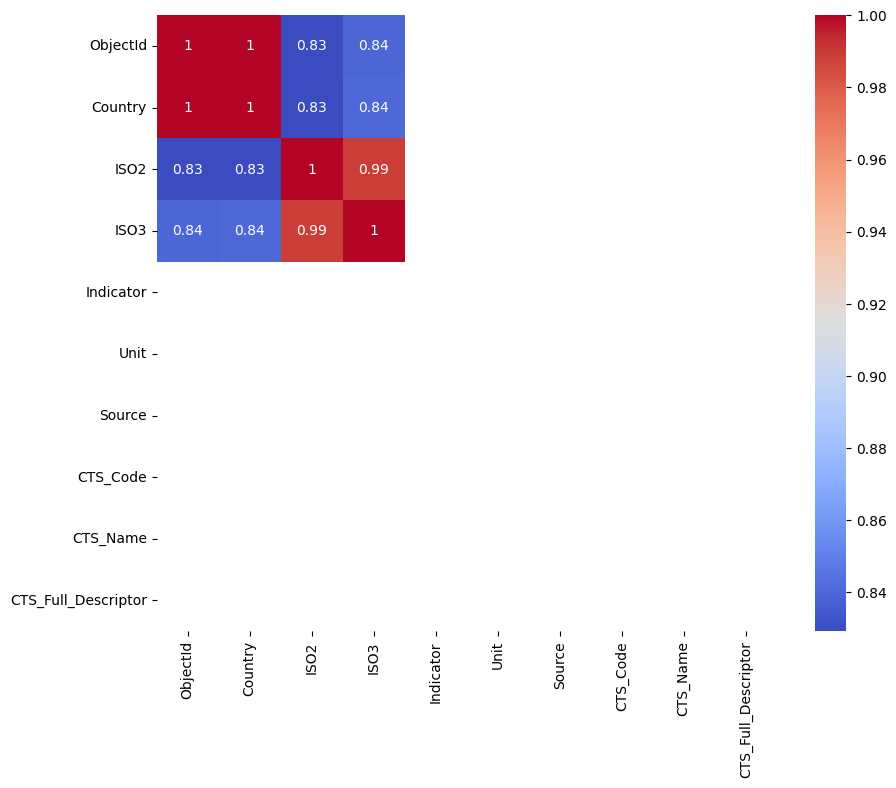

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

ask 9: Distribution Plot

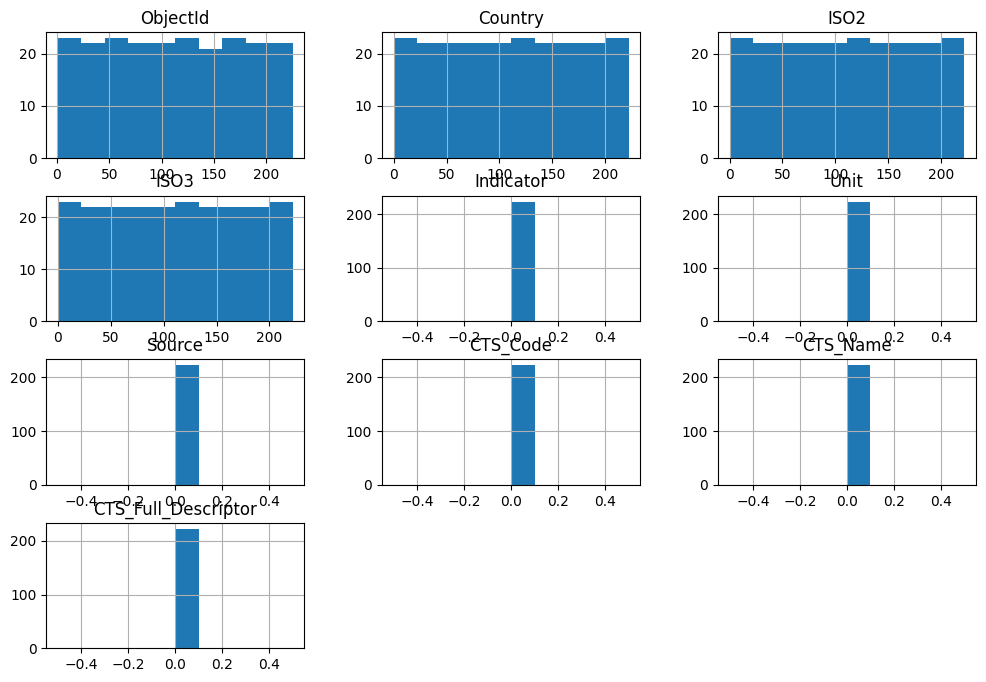

In [9]:
df.hist(figsize=(12,8))

plt.show()

Task 10: Feature Scaling

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(df)

Task 11: Elbow Method

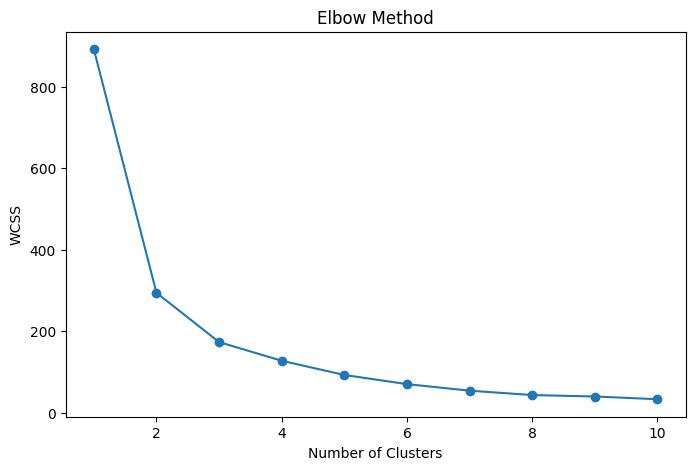

In [11]:
wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i,
                   random_state=42)

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Task 12: Apply K-Means

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,Cluster
0,1,0,2,1,0,0,0,0,0,0,2
1,2,1,5,4,0,0,0,0,0,0,2
2,3,2,51,53,0,0,0,0,0,0,2
3,4,3,9,9,0,0,0,0,0,0,2
4,5,4,0,5,0,0,0,0,0,0,2


Task 13: Visualize Clusters

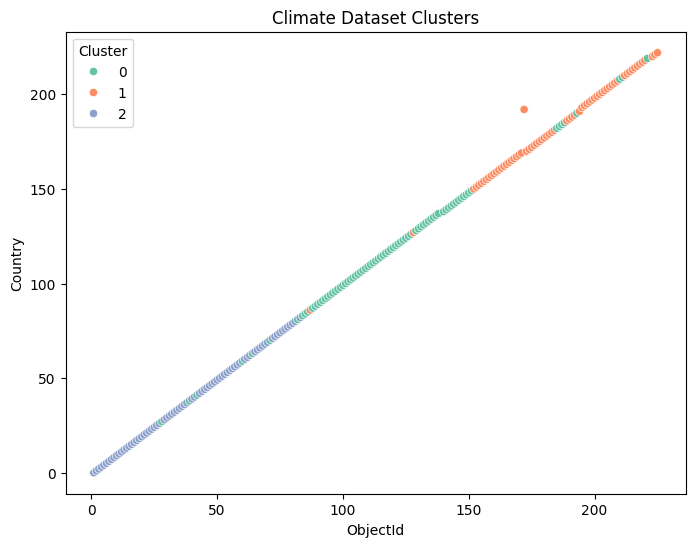

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["ObjectId"],
    y=df["Country"],
    hue=df["Cluster"],
    palette="Set2"
)

plt.title("Climate Dataset Clusters")

plt.show()

Task 14: Evaluate Model

In [14]:
score = silhouette_score(X, df["Cluster"])

print("Silhouette Score :", score)

Silhouette Score : 0.5021442369669591


Task 15: Cluster Distribution

In [15]:
print(df["Cluster"].value_counts())

Cluster
0    80
2    76
1    67
Name: count, dtype: int64


Task 16: Cluster Summary

In [16]:
cluster_summary = df.groupby("Cluster").mean()

print(cluster_summary)

           ObjectId     Country        ISO2        ISO3  Indicator  Unit  \
Cluster                                                                    
0        120.037500  118.725000  114.250000  115.212500        0.0   0.0   
1        184.492537  182.552239  186.492537  186.134328        0.0   0.0   
2         40.789474   39.789474   41.026316   40.328947        0.0   0.0   

         Source  CTS_Code  CTS_Name  CTS_Full_Descriptor  
Cluster                                                   
0           0.0       0.0       0.0                  0.0  
1           0.0       0.0       0.0                  0.0  
2           0.0       0.0       0.0                  0.0  


Based on the tasks performed, here is a summary and conclusion of the climate change indicators dataset:

Summary:
 1. Data Loading and Preprocessing: The dataset climate_change_indicators-selected-columns.csv was loaded. Missing values were handled by dropping 2 rows with nulls in ISO2, and no duplicate records were found.
 2. Feature Encoding: All categorical columns (Country, ISO2, ISO3, Indicator, Unit, Source, CTS_Code, CTS_Name, CTS_Full_Descriptor) were label encoded.
Data Characteristics: The correlation heatmap and distribution plots revealed that Indicator, Unit, Source, CTS_Code, CTS_Name, and CTS_Full_Descriptor columns were effectively constant or had a single unique value across the dataset after encoding, showing a value of 0 for all entries. This means they did not contribute meaningfully to the variance for clustering. The ObjectId, Country, ISO2, and ISO3 columns, after encoding, displayed a more distributed range of values.
 3. Feature Scaling: The entire dataset df was scaled using StandardScaler in preparation for K-Means clustering.
 4. K-Means Clustering: The Elbow Method suggested 2 or 3 as an optimal number of clusters. K-Means was then applied with n_clusters=3.
Cluster Evaluation: A Silhouette Score of approximately 0.50 was achieved, indicating a reasonable separation of the three clusters. The clusters had a fairly balanced distribution of 80, 76, and 67 members.
 5. Cluster Insights: The cluster visualization and summary of mean values per cluster showed that the clusters were primarily formed based on the values in ObjectId, Country, ISO2, and ISO3 columns. These columns, being identifier-like and then encoded, caused the clusters to represent different ranges of these identifiers.
  
  
  Conclusion:
The K-Means clustering successfully partitioned the dataset into three distinct groups. However, the analysis highlights a crucial aspect of the dataset: the columns related to the 'Indicator' itself (Indicator, Unit, Source, CTS_Code, CTS_Name, CTS_Full_Descriptor) appear to be uniform across all records. This suggests that the provided dataset, in its 'selected-columns' form, primarily contains metadata (like country identifiers) rather than varying numerical climate change indicator values that would typically drive meaningful climate-related clustering.

Therefore, the clusters formed are essentially groupings of countries/objects based on their encoded identifier characteristics, rather than on their actual climate change performance or trends. If the goal is to cluster countries based on climate change indicators, a dataset with varying numerical values for these indicators over time or across different types of indicators would be necessary. The current clustering provides a way to categorize the entries based on their descriptive metadata.

The df.head() output has been executed and reviewed. I previously provided a summary and conclusion of the entire dataset exploration and clustering. Do you have any further questions or tasks related to this analysis?